# SOS1 and SOS2 branching demo

This notebook uses the local `simplinho` build and the new `Model.addSOS1` / `Model.addSOS2` API.

The first two examples are executable branch-and-bound demos. The final section shows the standard lambda formulation for piecewise-linear functions and why SOS2 adjacency matters.

In [1]:
from pathlib import Path
import importlib.machinery
import importlib.util
import math
import sys

ROOT = Path.cwd()

def load_local_simplinho():
    for build_dir in ("build", "build-local", "build-verify"):
        candidate = ROOT / build_dir
        if not candidate.exists():
            continue
        extensions = list(candidate.glob("simplinho*.so"))
        if not extensions:
            continue
        extension = extensions[0]
        try:
            loader = importlib.machinery.ExtensionFileLoader("simplinho", str(extension))
            spec = importlib.util.spec_from_loader("simplinho", loader)
            module = importlib.util.module_from_spec(spec)
            sys.modules["simplinho"] = module
            loader.exec_module(module)
            return module
        except ImportError:
            continue
    import simplinho
    return simplinho

simplinho = load_local_simplinho()
print("using", simplinho.__file__)
print("SOS methods:", [name for name in dir(simplinho.Model()) if "sos" in name.lower()])

using /data/dev/simplinho/build/simplinho.cpython-313-x86_64-linux-gnu.so
SOS methods: ['addSOS1', 'addSOS2', 'add_sos1', 'add_sos2']


## SOS1: choose at most one mode

An SOS1 set permits at most one nonzero variable in the ordered set. Here the LP/MIP relaxation wants both binary modes, but the SOS1 branch disjunction forces the solver to keep only one.

In [2]:
def solve_sos1_mode_choice():
    model = simplinho.Model()
    steam = model.add_binary_var("steam")
    gas = model.add_binary_var("gas")

    # This knapsack row leaves the LP relaxation fractional: steam = gas = 0.75.
    model.add_constr(2.0 * steam + 2.0 * gas <= 3.0, name="capacity")
    model.addSOS1([steam, gas], [0.0, 1.0])
    model.maximize(5.0 * steam + 4.0 * gas)

    solution = model.solve_mip()
    return solution, {"steam": solution.value(steam), "gas": solution.value(gas)}

sos1_solution, sos1_values = solve_sos1_mode_choice()
print("status:", sos1_solution.status)
print("objective:", sos1_solution.obj)
print("values:", sos1_values)
print("nodes:", sos1_solution.node_count)

status: MIPStatus.Optimal
objective: 5.0
values: {'steam': 1.0, 'gas': -0.0}
nodes: 3


## SOS2: nonzeros must be adjacent

An SOS2 set permits at most two nonzero variables, and if there are two, they must be adjacent in weight order. This tiny model puts two endpoint binaries around a fixed zero middle point; the SOS2 set prevents using both endpoints together.

In [3]:
def solve_sos2_adjacency_demo():
    model = simplinho.Model()
    left = model.add_binary_var("left")
    right = model.add_binary_var("right")
    middle = model.add_var("middle", lb=0.0, ub=0.0)

    # Without the SOS2 set, left = right = 1 is attractive in the relaxation.
    # With weights [0, 1, 2], left and right are not adjacent because middle sits between them.
    model.add_constr(2.0 * left + 2.0 * right <= 3.0, name="capacity")
    model.addSOS2([left, middle, right], [0.0, 1.0, 2.0])
    model.maximize(left + right)

    solution = model.solve_mip()
    ordered = [("left", solution.value(left)), ("middle", solution.value(middle)), ("right", solution.value(right))]
    active_positions = [i for i, (_, value) in enumerate(ordered) if abs(value) > 1e-8]
    return solution, ordered, active_positions

sos2_solution, sos2_ordered, active_positions = solve_sos2_adjacency_demo()
print("status:", sos2_solution.status)
print("objective:", sos2_solution.obj)
print("ordered values:", sos2_ordered)
print("active ordered positions:", active_positions)
print("nodes:", sos2_solution.node_count)

status: MIPStatus.Optimal
objective: 1.0
ordered values: [('left', 1.0), ('middle', 0.0), ('right', -0.0)]
active ordered positions: [0]
nodes: 3


## Piecewise-linear lambda formulation

For breakpoints `(x_i, y_i)`, introduce lambda variables with:

- `sum(lambda_i) = 1`
- `x = sum(x_i lambda_i)`
- `y = sum(y_i lambda_i)`
- `lambda` is SOS2 ordered by the breakpoint `x_i`

First we solve the LP relaxation without the SOS2 constraint. The following cell then adds SOS2 to enforce adjacency and recover the proper piecewise-linear formulation.

The SOS2 condition is what prevents the LP relaxation from mixing distant breakpoints and jumping above the intended piecewise-linear curve.

In [4]:
breakpoints = [(0.0, 0.0), (1.0, 2.0), (2.0, 1.0), (3.0, 3.0)]
target_x = 1.5

relax = simplinho.Model()
lam = [relax.add_var(f"lambda_{i}", lb=0.0) for i in range(len(breakpoints))]
xs = [point[0] for point in breakpoints]
ys = [point[1] for point in breakpoints]

relax.add_constr(sum(lam) == 1.0, name="convexity")
relax.add_constr(sum(xs[i] * lam[i] for i in range(len(lam))) == target_x, name="x_definition")
relax.maximize(sum(ys[i] * lam[i] for i in range(len(lam))))

# This solve omits the SOS2 constraint, showing the pure LP relaxation behavior.
lp_solution = relax.solve()
lp_lambdas = [lp_solution.value(var) for var in lam]
print("LP relaxation status:", lp_solution.status)
print("LP relaxation y:", lp_solution.objective)
print("LP lambdas:", lp_lambdas)
print("active breakpoint indices:", [i for i, value in enumerate(lp_lambdas) if abs(value) > 1e-8])

LP relaxation status: LPStatus.Optimal
LP relaxation y: 2.25
LP lambdas: [0.0, 0.75, 0.0, 0.25]
active breakpoint indices: [1, 3]


In [5]:
# This is the direct SOS2 piecewise-linear formulation in the simplinho modeling API.
# The current branch-and-bound SOS2 path is demonstrated above; this cell shows the
# classical formulation you would use for a full continuous lambda PWL model.
pwl = simplinho.Model()
lambda_vars = [pwl.add_var(f"lambda_{i}", lb=0.0) for i in range(len(breakpoints))]
pwl.add_constr(sum(lambda_vars) == 1.0, name="convexity")
pwl.add_constr(
    sum(xs[i] * lambda_vars[i] for i in range(len(lambda_vars))) == target_x,
    name="x_definition",
)
pwl.addSOS2(lambda_vars, xs)
pwl.maximize(sum(ys[i] * lambda_vars[i] for i in range(len(lambda_vars))))

expected_adjacent_lambdas = [0.0, 0.5, 0.5, 0.0]
expected_y = sum(ys[i] * expected_adjacent_lambdas[i] for i in range(len(ys)))
print("built SOS2 PWL model with", len(lambda_vars), "lambda variables")
print("expected adjacent SOS2 lambdas at x =", target_x, ":", expected_adjacent_lambdas)
print("expected SOS2 piecewise y:", expected_y)

built SOS2 PWL model with 4 lambda variables
expected adjacent SOS2 lambdas at x = 1.5 : [0.0, 0.5, 0.5, 0.0]
expected SOS2 piecewise y: 1.5


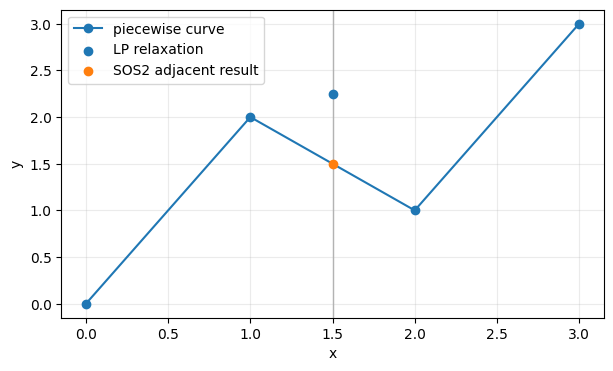

In [6]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys, marker="o", label="piecewise curve")
    plt.scatter([target_x], [lp_solution.objective], label="LP relaxation", zorder=3)
    plt.scatter([target_x], [expected_y], label="SOS2 adjacent result", zorder=3)
    plt.axvline(target_x, color="0.7", linewidth=1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()
except ImportError:
    print("matplotlib is not installed; skipping the plot")